In [5]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [6]:
df = pd.read_csv('bmw_global_sales_dataset.csv')

In [7]:
df.head()

,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   1000 non-null   int64  
 1   month                  1000 non-null   int64  
 2   country                1000 non-null   str    
 3   model                  1000 non-null   str    
 4   segment                1000 non-null   str    
 5   engine_type            1000 non-null   str    
 6   price_usd              1000 non-null   int64  
 7   marketing_spend_usd    1000 non-null   int64  
 8   dealership_count       1000 non-null   int64  
 9   fuel_price_usd         1000 non-null   float64
 10  gdp_growth_percent     1000 non-null   float64
 11  interest_rate_percent  1000 non-null   float64
 12  competition_index      1000 non-null   int64  
 13  units_sold             1000 non-null   int64  
dtypes: float64(3), int64(7), str(4)
memory usage: 109.5 KB


In [6]:
df.describe().astype(int)

,year,month,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
count,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
mean,2019,6,76535,279492,200,0,6,1,5,633
std,2,3,25360,127010,113,0,0,0,2,263
min,2015,1,35060,50363,10,0,6,1,1,15
25%,2017,3,54578,173552,101,0,6,1,3,432
50%,2019,7,75726,278733,197,0,6,1,6,630
75%,2022,10,98730,390110,297,0,6,1,8,842
max,2024,12,119817,498927,399,0,6,1,10,1242


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split

In [19]:
# yearly stats of units sold country wise

df1 = df.groupby('year')[['price_usd', 'marketing_spend_usd', 'units_sold']].sum()

In [34]:
df1

,price_usd,marketing_spend_usd,units_sold
year,,,
2015,9127616,33687210,76157
2016,6345401,21380293,53249
2017,8707911,29982491,69755
2018,6958779,28848190,58742
2019,7845844,28009015,71089
2020,7369022,26846112,61657
2021,7456643,24563472,56899
2022,7825467,28138507,60168
2023,7025628,26784146,57036


In [29]:
df1[['units_sold', 'marketing_spend_usd', 'price_usd']].apply(lambda x: print(type(x)))

<class 'pandas.Series'>
<class 'pandas.Series'>
<class 'pandas.Series'>


units_sold             None
marketing_spend_usd    None
price_usd              None
dtype: object

In [51]:
net = []
num = len(df1)
for i in range(num):
    price, ms, sold = df1.iloc[i, :].values
    net.append((price * sold) - ms)

In [53]:
df1['net'] = net

In [38]:
df1.iloc[:, :]

,price_usd,marketing_spend_usd,units_sold
year,,,
2015,9127616,33687210,76157
2016,6345401,21380293,53249
2017,8707911,29982491,69755
2018,6958779,28848190,58742
2019,7845844,28009015,71089
2020,7369022,26846112,61657
2021,7456643,24563472,56899
2022,7825467,28138507,60168
2023,7025628,26784146,57036


In [54]:
df1

,price_usd,marketing_spend_usd,units_sold,net
year,,,,
2015,9127616,33687210,76157,695098164502
2016,6345401,21380293,53249,337864877556
2017,8707911,29982491,69755,607390349314
2018,6958779,28848190,58742,408743747828
2019,7845844,28009015,71089,557725195101
2020,7369022,26846112,61657,454324943342
2021,7456643,24563472,56899,424250966585
2022,7825467,28138507,60168,470814559949
2023,7025628,26784146,57036,400686934462


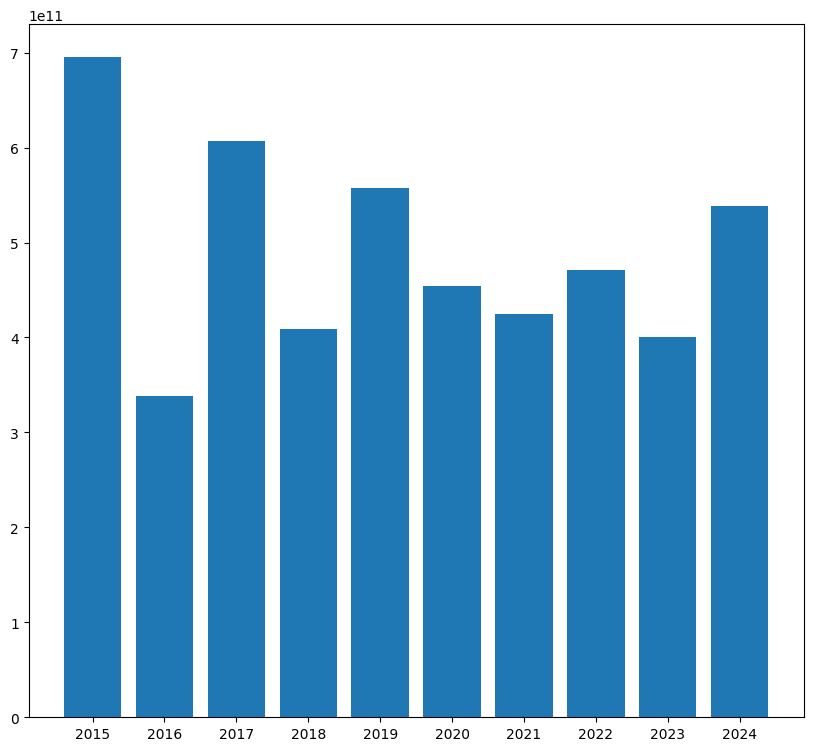

In [60]:
plt.figure(figsize=(10,9))
plt.bar(df1.index, df1['net'])
plt.xticks(df1.index)
plt.show()